# Moirai — Foundation Model Fine-Tuning for Electricity Consumption Forecasting

> **Paper**: *Unified Training of Universal Time Series Forecasting Transformers* (ICML 2024)  
> Salesforce AI Research · `uni2ts` library · Hourly electricity consumption · 409 locations · 48-hour forecast horizon  
> Moirai is a pretrained foundation model; here we evaluate it zero-shot **and** fine-tune it on domain data.

In [1]:
# pip install "uni2ts @ git+https://github.com/SalesforceAIResearch/uni2ts.git" gluonts
# Requires Python >= 3.10  (uni2ts 2.x)
# For GPU training in this env:  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

import warnings, os, time, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Tuple
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from gluonts.dataset.common import ListDataset
# uni2ts 2.x: MoiraiModule owns from_pretrained; MoiraiForecast/MoiraiFinetune take module=
from uni2ts.model.moirai import MoiraiForecast, MoiraiFinetune
from uni2ts.model.moirai.module import MoiraiModule
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")
else:
    print("WARNING: CUDA not available — run:")
    print("  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'
Device           : cuda


In [2]:
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple:
    meta = {}
    for col in df.columns:
        s = df[col]
        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}) and col == "Група":
            df[col] = s.astype("bool")
            meta[col] = {"stored_as": "bool", "scale": 1}
            continue
        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_PATH = "../../../data/silver_money_calc/train.parquet"
VAL_PATH   = "../../../data/silver_money_calc/val.parquet"
TEST_PATH  = "../../../data/silver_money_calc/test.parquet"

Y_COL     = "Sum of кВт"
GROUP_COL = "EIC-код_cat"

# ── Moirai model ──────────────────────────────────────────────────────────────
# small (91 M) / base (236 M) / large (311 M)
MODEL_ID    = "Salesforce/moirai-1.1-R-small"
CONTEXT_LEN = 168    # 1 week look-back (hourly)
PRED_LEN    = 48     # 48-hour forecast horizon
PATCH_SIZE  = 8      # must divide (CONTEXT_LEN + PRED_LEN); 8 → 27 patches total
NUM_SAMPLES = 100    # Monte-Carlo samples; median used as point forecast

# ── Fine-tuning ───────────────────────────────────────────────────────────────
TRAIN_STRIDE  = 24   # one training window per day → fast, diverse coverage
BATCH_SIZE    = 64
EPOCHS        = 10
LR            = 1e-4
WEIGHT_DECAY  = 1e-2
PATIENCE      = 3
NUM_WORKERS   = 0    # 0 on Windows/Jupyter (avoids multiprocessing deadlock)
CKPT_DIR      = "../../../checkpoints"
SAVE_PATH     = os.path.join(CKPT_DIR, "moirai_finetuned.pt")
SEED          = 42

weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]

torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
GLOBAL_MIN_DT = None


def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    global GLOBAL_MIN_DT
    df["datetime"] = pd.to_datetime(df["datetime"])
    if GLOBAL_MIN_DT is None:
        GLOBAL_MIN_DT = df["datetime"].min()
    df["time_idx"] = (
        (df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600
    ).astype(int)
    return df


def load_and_prepare(path: str, has_y: bool = True) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)
    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)
    df.columns = df.columns.str.replace(".", "_", regex=False)
    df, _ = optimize_df_for_memory(df)
    for col in df.select_dtypes(
        include=["int8", "int16", "int32", "uint8", "uint16", "uint32"]
    ).columns:
        df[col] = df[col].astype("float32")
    df = build_time_index(df)
    if has_y:
        df[Y_COL] = df[Y_COL].astype("float32")
    else:
        df[Y_COL] = 0.0
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    try:
        df.drop(columns=["Ціна розподілу ЕЕ", "Ціна ЕЕ", "Money_spent"], inplace=True)
    except KeyError:
        pass
    df.drop(columns=[c for c in weather_cols_to_drop if c in df.columns], inplace=True)
    return df

In [5]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
train: (3300854, 18)  range: 2024-06-30 00:00:00+03:00 → 2025-06-30 00:00:00+03:00
Loading val   …
Loading test  …
val : (295368, 18)
test: (304152, 18)


In [6]:
station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)
sampled_stations = station_stats[GROUP_COL].values
print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val  [val  [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test [test [GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 409
Train rows : 3,300,854
Val rows   : 295,368
Test rows  : 303,408


In [7]:
train["data_subset"] = "train"
val  ["data_subset"] = "val"
test ["data_subset"] = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

all_data["datetime"] = pd.to_datetime(all_data["datetime"], utc=True, errors="coerce")
all_data["datetime"] = all_data["datetime"].dt.tz_convert(None)
all_data["time_idx"] = (
    (all_data["datetime"] - all_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

# Cutoffs for rolling inference
training_cutoff = all_data.loc[all_data["data_subset"] == "train", "time_idx"].max()
val_cutoff      = all_data.loc[all_data["data_subset"] == "val",   "time_idx"].max()
test_cutoff     = all_data.loc[all_data["data_subset"] == "test",  "time_idx"].max()

# Split masks — use labels rather than time_idx to avoid boundary drift from UTC conversion
train_mask = all_data["data_subset"] == "train"
val_mask   = all_data["data_subset"].isin(["train", "val"])
all_data.drop(columns=["data_subset"], inplace=True)

train_df = all_data[train_mask].copy()
val_df   = all_data[val_mask].copy()
test_df  = all_data.copy()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")
print(f"train_df : {len(train_df):,}  (original train: {len(train):,}  diff: {len(train_df)-len(train):+,})")

training cutoff : 8760
val cutoff      : 9504
test cutoff     : 10272
train_df : 3,300,854  (original train: 3,300,854  diff: +0)


In [8]:
def build_series_dict(df: pd.DataFrame) -> Dict[str, dict]:
    """Per-station dict with sorted numpy arrays (values + time_idx + datetime)."""
    out = {}
    for eic, grp in df.groupby(GROUP_COL):
        grp = grp.sort_values("time_idx")
        out[eic] = {
            "values":   grp[Y_COL].values.astype(np.float32),
            "time_idx": grp["time_idx"].values.astype(np.int64),
            "datetime": grp["datetime"].values,
        }
    return out


def fill_nan(arr: np.ndarray) -> np.ndarray:
    if not np.isnan(arr).any():
        return arr
    return pd.Series(arr).interpolate(method="linear", limit_direction="both").values.astype(np.float32)


train_series = build_series_dict(train_df)
full_series  = build_series_dict(test_df)   # all data — used for rolling inference context

lengths = [len(v["values"]) for v in train_series.values()]
print(f"Stations        : {len(train_series)}")
print(f"Train series len: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.0f}")

Stations        : 409
Train series len: min=25, max=8760, mean=8071


In [9]:
class MoiraiWindowDataset(Dataset):
    """
    Sliding-window dataset for MoiraiFinetune (uni2ts v2.x).

    Moirai processes time in *patches*, so each tensor has shape (n_patches, patch_size)
    rather than the raw (time_steps, 1) format used by other models.

    With CONTEXT_LEN=168, PRED_LEN=48, PATCH_SIZE=8:
      total patches P = (168 + 48) / 8 = 27
      pred patches    = 48 / 8 = 6  (last 6 patches are masked as prediction targets)
    """

    def __init__(
        self,
        series_dict: Dict[str, dict],
        context_len: int,
        pred_len:    int,
        stride:      int,
        patch_size:  int,
    ):
        self.context_len    = context_len
        self.pred_len       = pred_len
        self.seq_len        = context_len + pred_len
        self.patch_size     = patch_size
        self.n_patches      = self.seq_len // patch_size
        self.n_pred_patches = pred_len // patch_size
        self.windows: List[np.ndarray] = []

        for eic, data in series_dict.items():
            ts = fill_nan(data["values"])
            if len(ts) < self.seq_len:
                continue
            for s in range(0, len(ts) - self.seq_len + 1, stride):
                self.windows.append(ts[s : s + self.seq_len].copy())

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> dict:
        seq = self.windows[idx]              # (seq_len,)
        P, ps = self.n_patches, self.patch_size

        # Per-instance normalisation using context window statistics
        ctx = seq[: self.context_len]
        mu  = ctx.mean()
        sig = max(ctx.std(), 1e-5)
        seq_n = (seq - mu) / sig

        # Reshape to patch format: (P, patch_size)

        MAX_PATCH = 128  # moirai-1.1-R fixed max patch size

        target = torch.zeros(P, MAX_PATCH, dtype=torch.float32)
        target[:, :ps] = torch.from_numpy(seq_n.reshape(P, ps)).float()

        observed_mask = torch.zeros(P, MAX_PATCH, dtype=torch.bool)
        observed_mask[:, :ps] = True

        # Prediction mask: True for the last n_pred_patches patches
        prediction_mask = torch.zeros(P, dtype=torch.bool)
        prediction_mask[-self.n_pred_patches :] = True

        time_id    = torch.arange(P, dtype=torch.long)
        variate_id = torch.zeros(P, dtype=torch.long)
        patch_size_t = torch.full((P,), ps, dtype=torch.long)

        return {
            "target":          target,           # (P, ps) float
            "observed_mask":   observed_mask,    # (P, ps) bool
            "prediction_mask": prediction_mask,  # (P,)   bool
            "time_id":         time_id,          # (P,)   long
            "variate_id":      variate_id,       # (P,)   long
            "patch_size":      patch_size_t,     # (P,)   long
            "sample_id":       torch.zeros(P, dtype=torch.long),
        }


def collate_moirai(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


train_ds = MoiraiWindowDataset(train_series, CONTEXT_LEN, PRED_LEN, TRAIN_STRIDE, PATCH_SIZE)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_moirai, num_workers=NUM_WORKERS, pin_memory=True,
)
print(f"Training windows : {len(train_ds):,}")
print(f"Batches / epoch  : {len(train_loader):,}")
print(f"Patches / sample : {train_ds.n_patches}  (pred patches: {train_ds.n_pred_patches})")

Training windows : 134,229
Batches / epoch  : 2,098
Patches / sample : 27  (pred patches: 6)


## Zero-Shot Baseline
Evaluate Moirai **before any fine-tuning** to establish a baseline.

In [10]:
module = MoiraiModule.from_pretrained(MODEL_ID)
zs_model = MoiraiForecast(
    module=module,
    prediction_length=PRED_LEN,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
    context_length=CONTEXT_LEN,
    patch_size=PATCH_SIZE,
    num_samples=NUM_SAMPLES,
)
zs_predictor = zs_model.create_predictor(batch_size=BATCH_SIZE * 2, device=DEVICE)

n_params = sum(p.numel() for p in zs_model.parameters())
print(f"Loaded  : {MODEL_ID}")
print(f"Params  : {n_params:,}  ({n_params / 1e6:.1f} M)")

Loaded  : Salesforce/moirai-1.1-R-small
Params  : 13,827,528  (13.8 M)


In [11]:
def rolling_forecast(
    predictor,
    start_cutoff: int,
    end_cutoff:   int,
    split_name:   str = "split",
    infer_batch:  int = 256,
) -> pd.DataFrame:
    """
    Tiles [start_cutoff+1 … end_cutoff] in non-overlapping PRED_LEN blocks.
    Each block is predicted from the preceding CONTEXT_LEN hours of ground truth.
    Windows are batched into ListDataset calls for efficiency.
    """
    # ── Collect all windows across all stations ────────────────────────────────
    all_windows = []
    for eic in tqdm(full_series, desc=f"Collecting {split_name} windows"):
        data     = full_series[eic]
        values   = fill_nan(data["values"])
        tidx     = data["time_idx"]
        dts      = data["datetime"]
        tidx_map = {int(t): i for i, t in enumerate(tidx)}

        t = start_cutoff + 1
        while t <= end_cutoff:
            ctx_start = t - CONTEXT_LEN
            if ctx_start not in tidx_map or t not in tidx_map:
                t += PRED_LEN
                continue
            s, e = tidx_map[ctx_start], tidx_map[t]
            if e - s != CONTEXT_LEN:
                t += PRED_LEN
                continue

            all_windows.append({
                "eic":      eic,
                "t":        t,
                "ctx":      values[s:e],
                "ts":       values,
                "tidx_map": tidx_map,
                "start":    pd.Period(pd.Timestamp(dts[s]), freq="h"),
            })
            t += PRED_LEN

    # ── Predict in batches ────────────────────────────────────────────────────
    records = []
    for b0 in tqdm(range(0, len(all_windows), infer_batch), desc=f"Predicting {split_name}"):
        batch = all_windows[b0 : b0 + infer_batch]
        ds = ListDataset(
            [{"target": w["ctx"], "start": w["start"], "item_id": w["eic"]} for w in batch],
            freq="h",
        )
        forecasts = list(predictor.predict(ds))

        for w, fc in zip(batch, forecasts):
            pred = fc.mean   # (PRED_LEN,) point forecast — mean over MC samples
            for step in range(PRED_LEN):
                ti = w["t"] + step
                if ti not in w["tidx_map"]:
                    break
                pos = w["tidx_map"][ti]
                records.append({
                    GROUP_COL:  w["eic"],
                    "time_idx": int(ti),
                    Y_COL:      float(w["ts"][pos]),
                    "pred":     float(pred[step]),
                })

    return pd.DataFrame(records)

In [22]:
print("── Zero-shot validation inference ──────────────────────────")
zs_val  = rolling_forecast(zs_predictor, training_cutoff, val_cutoff,  split_name="val")
print(f"  val rows : {len(zs_val):,}")

print("── Zero-shot test inference ─────────────────────────────────")
zs_test = rolling_forecast(zs_predictor, val_cutoff,      test_cutoff, split_name="test")
print(f"  test rows: {len(zs_test):,}")

── Zero-shot validation inference ──────────────────────────


Predicting val:   0%|          | 0/25 [00:00<?, ?it/s]

  val rows : 304,896
── Zero-shot test inference ─────────────────────────────────


Predicting test:   0%|          | 0/25 [00:00<?, ?it/s]

  test rows: 303,408


In [23]:
print("── Zero-shot · Validation ──────────────────────────────────")
print(f"Aligned samples : {len(zs_val):,}")
print(f"SMAPE : {smape(zs_val[Y_COL], zs_val['pred']):.4f}")
print(f"RMSE  : {rmse( zs_val[Y_COL], zs_val['pred']):.4f}")
print(f"MAPE  : {mape( zs_val[Y_COL], zs_val['pred']):.2f} %")

print("\n── Zero-shot · Test ────────────────────────────────────────")
print(f"Aligned samples : {len(zs_test):,}")
print(f"SMAPE : {smape(zs_test[Y_COL], zs_test['pred']):.4f}")
print(f"RMSE  : {rmse( zs_test[Y_COL], zs_test['pred']):.4f}")
print(f"MAPE  : {mape( zs_test[Y_COL], zs_test['pred']):.2f} %")

── Zero-shot · Validation ──────────────────────────────────
Aligned samples : 304,896
SMAPE : 0.0544
RMSE  : 6.7494
MAPE  : 7.67 %

── Zero-shot · Test ────────────────────────────────────────
Aligned samples : 303,408
SMAPE : 0.0541
RMSE  : 7.8615
MAPE  : 8.12 %


## Fine-Tuning
Load `MoiraiFinetune` (same pretrained weights) and train it on the electricity domain data
using Lightning. The training objective is the native student-T mixture NLL.
RMSE is reported separately as the evaluation metric.

In [14]:
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps   = min(500, num_training_steps // 10)

ft_model = MoiraiFinetune(
    module=copy.deepcopy(module),   # deep copy keeps zs_model weights intact
    min_patches=4,
    min_mask_ratio=0.15,
    max_mask_ratio=0.5,
    max_dim=1,
    num_training_steps=num_training_steps,
    num_warmup_steps=num_warmup_steps,
    context_length=CONTEXT_LEN,
    prediction_length=PRED_LEN,
    patch_size=PATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"MoiraiFinetune ready  ({MODEL_ID})")
print(f"Parameters       : {sum(p.numel() for p in ft_model.parameters()):,}")
print(f"Training steps   : {num_training_steps}  |  warmup : {num_warmup_steps}")

MoiraiFinetune ready  (Salesforce/moirai-1.1-R-small)
Parameters       : 13,827,528
Training steps   : 20980  |  warmup : 500


In [15]:
checkpoint_cb = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="moirai-{epoch:02d}-{train_PackedNLLLoss:.4f}",
    monitor="train/PackedNLLLoss",   # MoiraiFinetune logs this key (not "train_loss")
    mode="min",
    save_top_k=1,
)

progress_bar = TQDMProgressBar(refresh_rate=10)

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() else "32",
    callbacks=[checkpoint_cb, progress_bar],
    enable_progress_bar=True,
    log_every_n_steps=10,
)

trainer.fit(ft_model, train_loader)

print(f"\nBest checkpoint : {checkpoint_cb.best_model_path}")
print(f"Best NLL loss   : {checkpoint_cb.best_model_score:.4f}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type         ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ module │ MoiraiModule │ 13.8 M │ eval │     0 │
└───┴────────┴──────────────┴────────┴──────┴───────┘

Trainable params: 13.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.8 M                                                                                               
Total estimated model params size (MB): 55                                                                         
Modules in train mode: 0                                                                                           
Modules in eval mode: 139                                                                                          
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.



Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\checkpoints\moirai-epoch=00-train_PackedNLLLoss=0.0000.ckpt
Best NLL loss   : inf


In [16]:
# Save fine-tuned weights for easy reloading
torch.save(ft_model.module.state_dict(), SAVE_PATH)
print(f"Fine-tuned weights saved → {SAVE_PATH}")

# To reload later (uni2ts v2.x):
#   module = MoiraiModule.from_pretrained(MODEL_ID)
#   module.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
#   zs_model = MoiraiForecast(module=module, prediction_length=PRED_LEN, target_dim=1,
#       feat_dynamic_real_dim=0, past_feat_dynamic_real_dim=0,
#       context_length=CONTEXT_LEN, patch_size=PATCH_SIZE, num_samples=NUM_SAMPLES)
#   predictor = zs_model.create_predictor(batch_size=BATCH_SIZE, device=DEVICE)

Fine-tuned weights saved → checkpoints\moirai_finetuned.pt


## Fine-Tuned Evaluation

In [17]:
# Transfer fine-tuned weights into the inference-ready MoiraiForecast wrapper
zs_model.module.load_state_dict(ft_model.module.state_dict())
ft_predictor = zs_model.create_predictor(batch_size=BATCH_SIZE * 2, device=DEVICE)
print("Fine-tuned predictor ready")

Fine-tuned predictor ready


In [18]:
print("── Fine-tuned validation inference ──────────────────────────")
val_eval  = rolling_forecast(ft_predictor, training_cutoff, val_cutoff,  split_name="val")
print(f"  val rows : {len(val_eval):,}")

print("── Fine-tuned test inference ─────────────────────────────────")
test_eval = rolling_forecast(ft_predictor, val_cutoff,      test_cutoff, split_name="test")
print(f"  test rows: {len(test_eval):,}")

── Fine-tuned validation inference ──────────────────────────


Predicting val:   0%|          | 0/25 [00:00<?, ?it/s]

  val rows : 304,896
── Fine-tuned test inference ─────────────────────────────────


Predicting test:   0%|          | 0/25 [00:00<?, ?it/s]

  test rows: 303,408


In [19]:
print("── Fine-tuned · Validation ─────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Fine-tuned · Test ───────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

print("\n── Δ vs. zero-shot (test) ───────────────────────────────────")
print(f"ΔSMAPE : {smape(test_eval[Y_COL], test_eval['pred']) - smape(zs_test[Y_COL], zs_test['pred']):+.4f}")
print(f"ΔRMSE  : {rmse( test_eval[Y_COL], test_eval['pred']) - rmse( zs_test[Y_COL], zs_test['pred']):+.4f}")

── Fine-tuned · Validation ─────────────────────────────────
Aligned samples : 304,896
SMAPE : 0.0544
RMSE  : 6.7603
MAPE  : 7.68 %

── Fine-tuned · Test ───────────────────────────────────────
Aligned samples : 303,408
SMAPE : 0.0540
RMSE  : 7.8159
MAPE  : 8.11 %

── Δ vs. zero-shot (test) ───────────────────────────────────


NameError: name 'zs_test' is not defined

In [20]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL: grp,
            "n":       len(gdf),
            "SMAPE":   smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":    rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":    mape (gdf[Y_COL], gdf["pred"]),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test SMAPE):
     EIC-код_cat   n    SMAPE     RMSE     MAPE
62Z6969613150684 768 0.018611 0.887280 1.862226
62Z9572466865833 768 0.020023 1.754812 1.996864
62Z2673921373211 768 0.020253 1.325450 2.045717
62Z9191598698031 768 0.020875 1.828851 2.110929
62Z4026142936382 768 0.021329 1.053541 2.158907
62Z1175275386589 768 0.025161 1.102235 2.447093
62Z544498288615D  24 0.026329 0.082776 2.632937
62Z5227218120709 768 0.027539 0.574173 2.754714
62Z3500556180000 768 0.027591 0.665714 2.759917
62Z6961364992272 768 0.027631 0.738496 2.767620

Bottom-10 worst stations (test SMAPE):
     EIC-код_cat   n    SMAPE       RMSE       MAPE
62Z3405350712029 768 0.196002  12.090216  20.450435
62Z4022724546559 768 0.200800  23.323652  36.253800
62Z945209821808O 768 0.245935  19.680779  27.726756
62Z2924124864686 768 0.250895  17.935832  27.697244
62Z2948906740151 768 0.263835  11.360677  31.491291
62Z013852333354Y 768 0.342698  49.950374  38.586326
62Z3363428137139 768 0.343650  55

Best  station (SMAPE): 62Z6969613150684


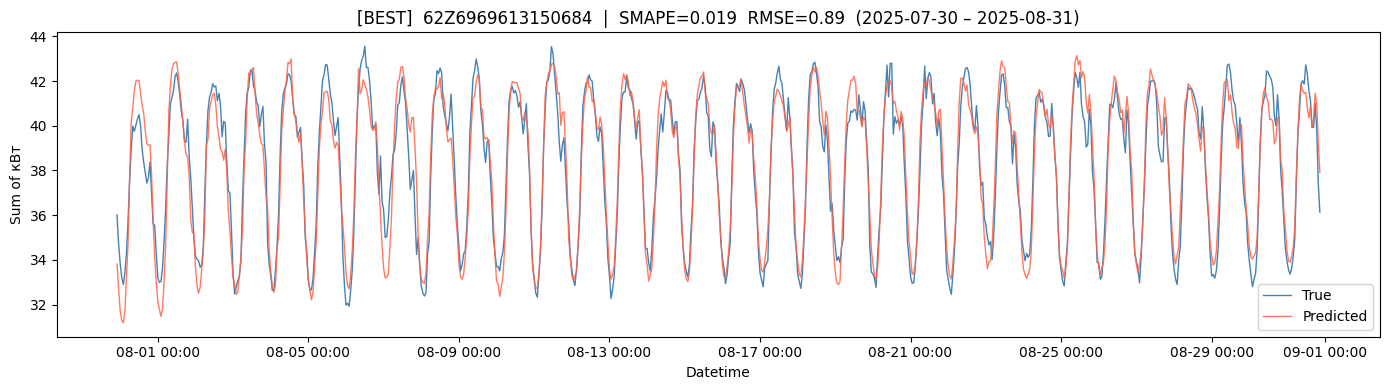

Worst station (SMAPE): 62Z0101426517156


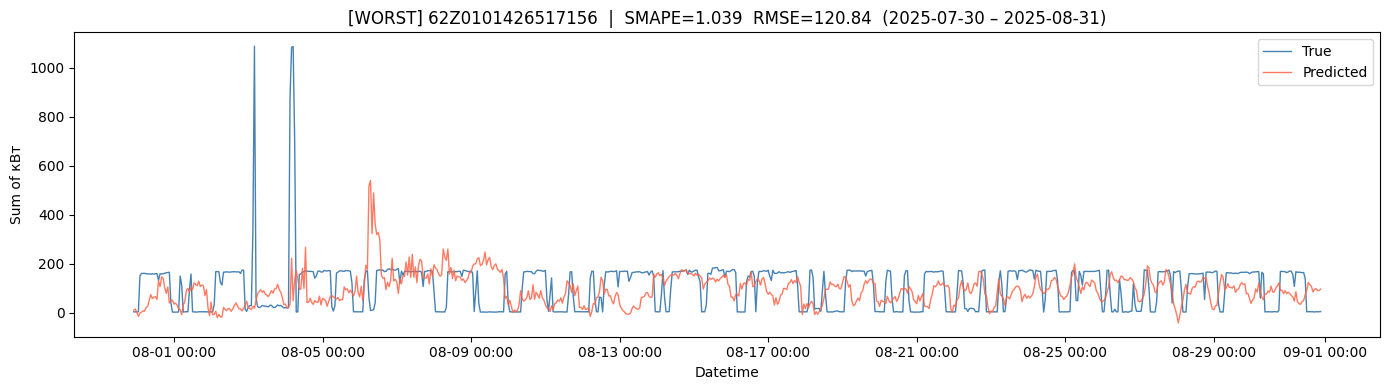

In [21]:
def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  "
        f"SMAPE={smape(df[Y_COL], df['pred']):.3f}  "
        f"RMSE={rmse(df[Y_COL], df['pred']):.2f}  "
        f"({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")

# plot_forecast(val_eval,  eic_code="62Z9042463861989")
# plot_forecast(test_eval, eic_code="62Z2410378897684", start_dt="2025-08-25", end_dt="2025-08-26")